# GLM-5.3-Flash on 4× CMP 170HX: Morrowmake recipe v1.7.0 on a PLX host, TP4 vs PP4, P2P, power and link width

| Measured: TP4 + P2P, `GLM5_NCCL_P2P_SYS=0`, 140 W | One card x8 (sections 2–7) | **All four x16, loop fix (served now, section 8)** |
|---|---:|---:|
| Decode, 1 user: structured / code / prose (tok/s) | 450.8 / 352.4 / 184.6 | **464.2 / 357.8 / 186.7** |
| Decode, 8 users total: structured / code / prose (tok/s) | 762.4 / 616.9 / 498.5 | **845.7 / 670.7 / 543.5** |
| Cold prefill, 19k–36k tokens (tok/s) | 1,789–1,911 | **2,524–2,769** |
| KV pool at 262,144 context (tokens) | 1,198,522 | 1,199,570 |

CAUTION: the stock v1.7.0 image breaks long generations at TP4: the output switches mid-word and then repeats one token (13 of 24 broken in our test). The cause is an off-by-one in the RecoverSSM state commit ([recipe issue #7](https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe/issues/7)). Serve the fixed image `ghcr.io/pixelml/club-170hx@sha256:f9fc947bb4f1fdacd5e146948cb64cdca01da0942809989d32a6241886defaf0` (same speed, 0 of 20 broken), see the [fix notebook](2026-10-04-glm-5.3-flash-v1.7.0-recoverssm-loop-fix-4card-tp4-vllm.ipynb).

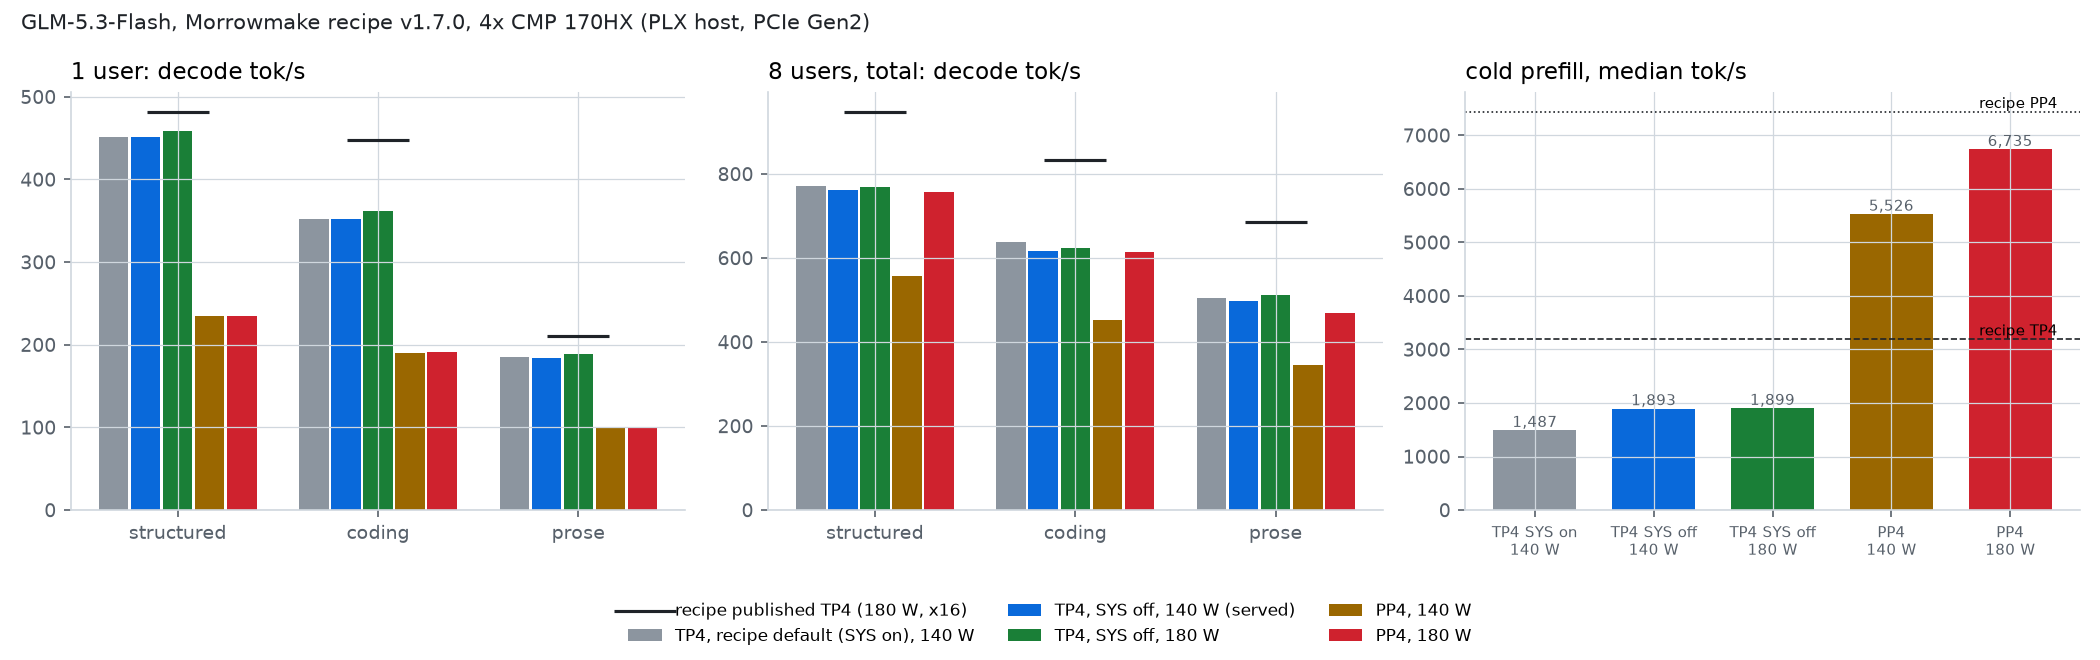

**Verdict (measured):** the [Morrowmake recipe](https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe) v1.7.0 runs on this 4-card PLX host with P2P after one launcher change (`--gpus all` → CDI device) and, for long generations, the RecoverSSM loop fix. With all four cards at x16, the served configuration reaches 96% / 80% / 89% of the recipe's published TP4 single-user figures (structured / code / prose), 79–89% for eight users and 79–87% on prefill. P2P on is 10–11% faster for one user than P2P off; P2P off prefills 10% faster (section 8).

Sections 2–7 were measured earlier the same day, when one card linked at x8: there, `GLM5_NCCL_P2P_SYS=0` made TP4 prefill 25–57% faster, 180 W changed TP4 by 1–3%, and PP4 at 180 W prefilled 3.5× faster than TP4 but decoded one user at half the speed. Moving that card to x16 raised TP4 prefill 41–45% and eight-user decode 9–11% (section 8).

```
docker pull ghcr.io/pixelml/club-170hx@sha256:f9fc947bb4f1fdacd5e146948cb64cdca01da0942809989d32a6241886defaf0   # served: v1.7.0 + loop fix
docker pull ghcr.io/morrowmake/vllm-cmp170hx@sha256:158627a705b6ae24fa63ba6eb454982454c5e6b94b1e32981faf33eb81a7ea3e   # recipe v1.7.0 (sections 2-7)
```

In [1]:
# --- Status cell ---
import os
EXPERIMENT = "2026-10-04-glm-5.3-flash-morrowmake-v1.7.0-4card-tp4-pp4-p2p-vllm"
RESULTS_DIR = "../results/" + EXPERIMENT
RECEIPTS = RESULTS_DIR + "/receipts"
LIVE = False  # True sends the final request to the endpoint in GLM_URL (an OpenAI-compatible /v1 base)
ENDPOINT_ENV_VAR = "GLM_URL"
print("LIVE =", LIVE, "| receipts:", RECEIPTS)

LIVE = False | receipts: ../results/2026-10-04-glm-5.3-flash-morrowmake-v1.7.0-4card-tp4-pp4-p2p-vllm/receipts


In [2]:
# --- Helpers ---
import json, csv, statistics
from IPython.display import display, Markdown
import matplotlib
import matplotlib.pyplot as plt

def load(*parts):
    p = "/".join(parts)
    return json.load(open(p)) if os.path.exists(p) else None

def table(header, rows):
    out = ["| " + " | ".join(header) + " |", "|" + "|".join("---:" if i else "---" for i in range(len(header))) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))

PROMPTS = ("structured", "coding", "prose")
def dec(run, p, c):
    d = load(RECEIPTS, run, f"decode-{p}-c{c}.json") or {}
    return d.get("aggregate_tok_s_median") if c > 1 else d.get("tok_s_median")
def acc(run, p, c):
    return (load(RECEIPTS, run, f"decode-{p}-c{c}.json") or {}).get("accepted_per_step_median")
def prefill(run):
    d = load(RECEIPTS, run, "prefill.json") or {}
    return [r["prefill_tok_s"] for r in d.get("results", [])]

INK, INK2, GRID = "#1f2328", "#57606a", "#d0d7de"
S = ["#8c959f", "#0969da", "#1a7f37", "#9a6700", "#cf222e"]
matplotlib.rcParams.update({"axes.edgecolor": GRID, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
                            "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
                            "axes.spines.right": False, "font.size": 9})
RUNS = [("glm53-v170-tp4-p2p", "TP4, recipe default (SYS on), 140 W"),
        ("glm-v170-tp4-nosys-140", "TP4, SYS off, 140 W (served)"),
        ("glm-v170-tp4-nosys-180", "TP4, SYS off, 180 W"),
        ("glm-v170-pp4-140", "PP4, 140 W"),
        ("glm-v170-pp4-180", "PP4, 180 W")]
THEIRS = {"TP4": {"c1": (482.2, 447.7, 210.6), "c8": (948.6, 834.1, 684.6), "prefill": 3197}, "PP4": {"prefill": 7444}}

## 1. TL;DR

- **Measured, served (all four cards x16, loop fix, TP4, SYS off, P2P on, 140 W):** 464.2 / 357.8 / 186.7 tok/s for one user (structured / code / prose), 845.7 / 670.7 / 543.5 tok/s for eight users, 2,524–2,769 tok/s prefill: 96% / 80% / 89%, 79–89% and 79–87% of the recipe's published TP4 figures.
- **Measured:** the recipe's content-verified P2P check passes on this host (12 card pairs, 9 sizes, 15.5 s). The engine then uses the flags-in-data custom all-reduce for messages up to 256 KiB and NCCL above.
- **Measured, one card x8:** with the recipe defaults (TP4, 140 W), single-user decode is 451.7 / 351.8 / 184.7 tok/s: 94% / 79% / 88% of the recipe's published TP4 figures (180 W, x16 links).
- **Measured, one card x8:** `GLM5_NCCL_P2P_SYS=0` (do not force `NCCL_P2P_LEVEL=SYS`) raises TP4 prefill from 1,140–1,530 to 1,789–1,911 tok/s. Decode does not change.
- **Measured, one card x8:** 180 W instead of 140 W changes TP4 by only 1–3%. PP4 gains 36% on eight-user decode and about 20% on prefill.
- **Measured, one card x8:** PP4 at 180 W prefills 6,359–7,151 tok/s (recipe: 7,444). Its single-user decode is about half of TP4.
- **Measured:** against recipe 1.6.0 on this host (P2P off, 140 W), 1.7.0 is 9% and 15% faster on single-user structured and code, and 13% slower on prose.
- **Measured (section 8):** with all four cards at x16, TP4 prefill rises 41–45% and eight-user decode 9–11%. One user gains 1–3%.
- **Measured (section 8):** at x16, P2P on (the recipe's verified custom all-reduce) is 10–11% faster for one user than P2P off. P2P off (host shared-memory all-reduce) prefills 10% faster and is 4–6% faster for eight users on code and prose.
- **Measured (fix notebook):** the stock image loops on long generations at TP4 (RecoverSSM off-by-one); the fixed image removes it at the same speed.
- **Served:** TP4, SYS off, P2P on, 140 W, fixed image: the fastest replies for chat and agents.

In [3]:
pins = {
    "engine image": "ghcr.io/morrowmake/vllm-cmp170hx@sha256:158627a705b6ae24fa63ba6eb454982454c5e6b94b1e32981faf33eb81a7ea3e",
    "engine source": "Morrowmake/vllm-cmp170hx @ c1ce6491efe53934119d306d0a0501b475458e9b (release pin in the recipe)",
    "recipe": "Morrowmake/glm53-flash-cmp170hx-recipe @ e61ba680cd6f9497291cafa4ca13ac3ffbdab844 (v1.7.0); one local change: --gpus all -> --device nvidia.com/gpu=all (build/start.sh.patch)",
    "target model": "canada-quant/GLM-5.3-Flash-W4A16-MTP @ 5723f4d02af36366c23ace8668866ca7775855c1 (MIT; weights identical to 75ba0dbbc68f475f2538a789807843f5d1264220, which changed only README.md and BENCHMARKS.md)",
    "drafter": "incoai/GLM-5.3-Flash-DFlash2 @ bf582e4eacc1810f76656d1811693ff6c6737d2a (CC BY-NC-ND 4.0)",
    "driver": "NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504 (64 GiB, 74 SMs, BAR1 P2P)",
    "host": "Proxmox VE 9.2, kernel 7.0.2-6-pve; container in a privileged LXC sharing the host driver (GPUs by CDI)",
    "topology": "two PLX switches: cards 0-1 PIX, cards 2-3 PIX, cross pairs PHB; PCIe Gen2; sections 2-7: three x16 and one x8; section 8: all four x16 (after a host restart)",
    "power": "nvidia-smi -pl 140 (host default) or -pl 180 per run (receipts/<run>/nvidia-smi-start.csv)",
    "recipe .env (served)": "LAYOUT=tp4 HOST=0.0.0.0 PORT=8030 P2P=auto GLM5_NCCL_P2P_SYS=0 MODELS_DIR=<models>; since the loop fix also IMAGE=ghcr.io/pixelml/club-170hx@sha256:f9fc947bb4f1fdacd5e146948cb64cdca01da0942809989d32a6241886defaf0",
}
table(["pin", "value"], pins.items())

| pin | value |
|---|---:|
| engine image | ghcr.io/morrowmake/vllm-cmp170hx@sha256:158627a705b6ae24fa63ba6eb454982454c5e6b94b1e32981faf33eb81a7ea3e |
| engine source | Morrowmake/vllm-cmp170hx @ c1ce6491efe53934119d306d0a0501b475458e9b (release pin in the recipe) |
| recipe | Morrowmake/glm53-flash-cmp170hx-recipe @ e61ba680cd6f9497291cafa4ca13ac3ffbdab844 (v1.7.0); one local change: --gpus all -> --device nvidia.com/gpu=all (build/start.sh.patch) |
| target model | canada-quant/GLM-5.3-Flash-W4A16-MTP @ 5723f4d02af36366c23ace8668866ca7775855c1 (MIT; weights identical to 75ba0dbbc68f475f2538a789807843f5d1264220, which changed only README.md and BENCHMARKS.md) |
| drafter | incoai/GLM-5.3-Flash-DFlash2 @ bf582e4eacc1810f76656d1811693ff6c6737d2a (CC BY-NC-ND 4.0) |
| driver | NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504 (64 GiB, 74 SMs, BAR1 P2P) |
| host | Proxmox VE 9.2, kernel 7.0.2-6-pve; container in a privileged LXC sharing the host driver (GPUs by CDI) |
| topology | two PLX switches: cards 0-1 PIX, cards 2-3 PIX, cross pairs PHB; PCIe Gen2; sections 2-7: three x16 and one x8; section 8: all four x16 (after a host restart) |
| power | nvidia-smi -pl 140 (host default) or -pl 180 per run (receipts/<run>/nvidia-smi-start.csv) |
| recipe .env (served) | LAYOUT=tp4 HOST=0.0.0.0 PORT=8030 P2P=auto GLM5_NCCL_P2P_SYS=0 MODELS_DIR=<models>; since the loop fix also IMAGE=ghcr.io/pixelml/club-170hx@sha256:f9fc947bb4f1fdacd5e146948cb64cdca01da0942809989d32a6241886defaf0 |

## 2. Five configurations (measured, one card at x8)

Decode: `bench_decode.py` (MiaAI-Lab prompts, the recipe's protocol): 400 tokens, temperature 0, thinking off; one user is the median of 5 runs, eight users the median aggregate of 3 runs, all on one boot. Prefill: `bench_long.py`: real text with a unique prefix, `max_tokens=1`, two prompts each near 24k, 30k and 38k target tokens. One boot per configuration, recipe defaults except the column labels.

In [4]:
rows = []
for run, lab in RUNS:
    pf = prefill(run)
    rows.append([lab] + [f"{dec(run, p, 1):.1f}" for p in PROMPTS] + [f"{dec(run, p, 8):.1f}" for p in PROMPTS]
                + [f"{min(pf):,.0f}–{max(pf):,.0f}" if pf else "–"])
rows.append(["Recipe v1.7.0 published, TP4 (180 W, x16)"] + [f"{v}" for v in THEIRS["TP4"]["c1"]] + [f"{v}" for v in THEIRS["TP4"]["c8"]] + ["3,197"])
rows.append(["Recipe v1.7.0 published, PP4 (180 W, x16)"] + ["–"] * 6 + ["7,444"])
table(["configuration", "1u struct", "1u code", "1u prose", "8u struct", "8u code", "8u prose", "prefill tok/s"], rows)
table(["configuration", "accepted per step, 1u struct / code / prose", "8u struct / code / prose"],
      [[lab, " / ".join(f"{acc(r, p, 1):.2f}" for p in PROMPTS), " / ".join(f"{acc(r, p, 8):.2f}" for p in PROMPTS)] for r, lab in RUNS])

| configuration | 1u struct | 1u code | 1u prose | 8u struct | 8u code | 8u prose | prefill tok/s |
|---|---:|---:|---:|---:|---:|---:|---:|
| TP4, recipe default (SYS on), 140 W | 451.7 | 351.8 | 184.7 | 771.3 | 638.0 | 504.1 | 1,140–1,530 |
| TP4, SYS off, 140 W (served) | 450.8 | 352.4 | 184.6 | 762.4 | 616.9 | 498.5 | 1,789–1,911 |
| TP4, SYS off, 180 W | 458.5 | 361.7 | 189.1 | 769.0 | 624.0 | 511.5 | 1,787–1,916 |
| PP4, 140 W | 234.7 | 190.5 | 100.8 | 556.8 | 451.8 | 345.9 | 5,211–5,879 |
| PP4, 180 W | 235.4 | 191.0 | 101.0 | 756.2 | 614.7 | 468.0 | 6,359–7,151 |
| Recipe v1.7.0 published, TP4 (180 W, x16) | 482.2 | 447.7 | 210.6 | 948.6 | 834.1 | 684.6 | 3,197 |
| Recipe v1.7.0 published, PP4 (180 W, x16) | – | – | – | – | – | – | 7,444 |

| configuration | accepted per step, 1u struct / code / prose | 8u struct / code / prose |
|---|---:|---:|
| TP4, recipe default (SYS on), 140 W | 6.69 / 5.25 / 1.66 | 2.94 / 2.62 / 1.84 |
| TP4, SYS off, 140 W (served) | 6.69 / 5.25 / 1.66 | 2.94 / 2.62 / 1.84 |
| TP4, SYS off, 180 W | 6.69 / 5.25 / 1.66 | 2.94 / 2.62 / 1.84 |
| PP4, 140 W | 6.58 / 5.62 / 2.27 | 2.96 / 2.64 / 1.84 |
| PP4, 180 W | 6.58 / 5.62 / 2.27 | 2.96 / 2.64 / 1.79 |

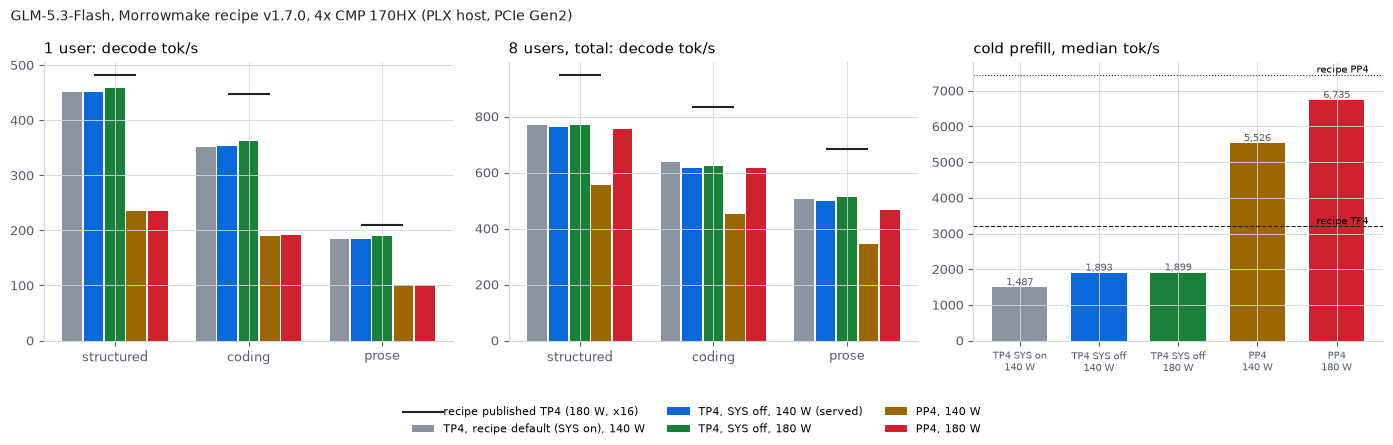

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
w = 0.16
for i, (run, lab) in enumerate(RUNS):
    for ax, c in ((axes[0], 1), (axes[1], 8)):
        ax.bar([j + (i - 2) * w for j in range(3)], [dec(run, p, c) for p in PROMPTS], w * 0.92, color=S[i], label=lab)
    pf = prefill(run)
    axes[2].bar(i, statistics.median(pf), 0.7, color=S[i])
    axes[2].text(i, statistics.median(pf), f"{statistics.median(pf):,.0f}", ha="center", va="bottom", fontsize=7, color=INK2)
for ax, c, key in ((axes[0], 1, "c1"), (axes[1], 8, "c8")):
    ax.scatter(range(3), THEIRS["TP4"][key], marker="_", s=900, color=INK, zorder=4, label="recipe published TP4 (180 W, x16)")
    ax.set_xticks(range(3), PROMPTS); ax.set_title(f"{'1 user' if c == 1 else '8 users, total'}: decode tok/s", loc="left")
axes[2].axhline(THEIRS["TP4"]["prefill"], color=INK, lw=0.8, ls="--"); axes[2].text(4.4, THEIRS["TP4"]["prefill"], "recipe TP4", va="bottom", ha="right", fontsize=7)
axes[2].axhline(THEIRS["PP4"]["prefill"], color=INK, lw=0.8, ls=":"); axes[2].text(4.4, THEIRS["PP4"]["prefill"], "recipe PP4", va="bottom", ha="right", fontsize=7)
axes[2].set_xticks(range(len(RUNS)), ["TP4 SYS on\n140 W", "TP4 SYS off\n140 W", "TP4 SYS off\n180 W", "PP4\n140 W", "PP4\n180 W"], fontsize=7)
axes[2].set_title("cold prefill, median tok/s", loc="left")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, fontsize=8, frameon=False)
fig.suptitle("GLM-5.3-Flash, Morrowmake recipe v1.7.0, 4x CMP 170HX (PLX host, PCIe Gen2)", x=0.01, ha="left", fontsize=10, color=INK)
fig.tight_layout(rect=(0, 0.12, 1, 1))
os.makedirs("../assets/charts", exist_ok=True)
fig.savefig(f"../assets/charts/{EXPERIMENT}.png", dpi=150); fig.savefig(f"../assets/charts/{EXPERIMENT}.svg")
plt.show()

## 3. The NCCL P2P level (measured at x8, inferred cause)

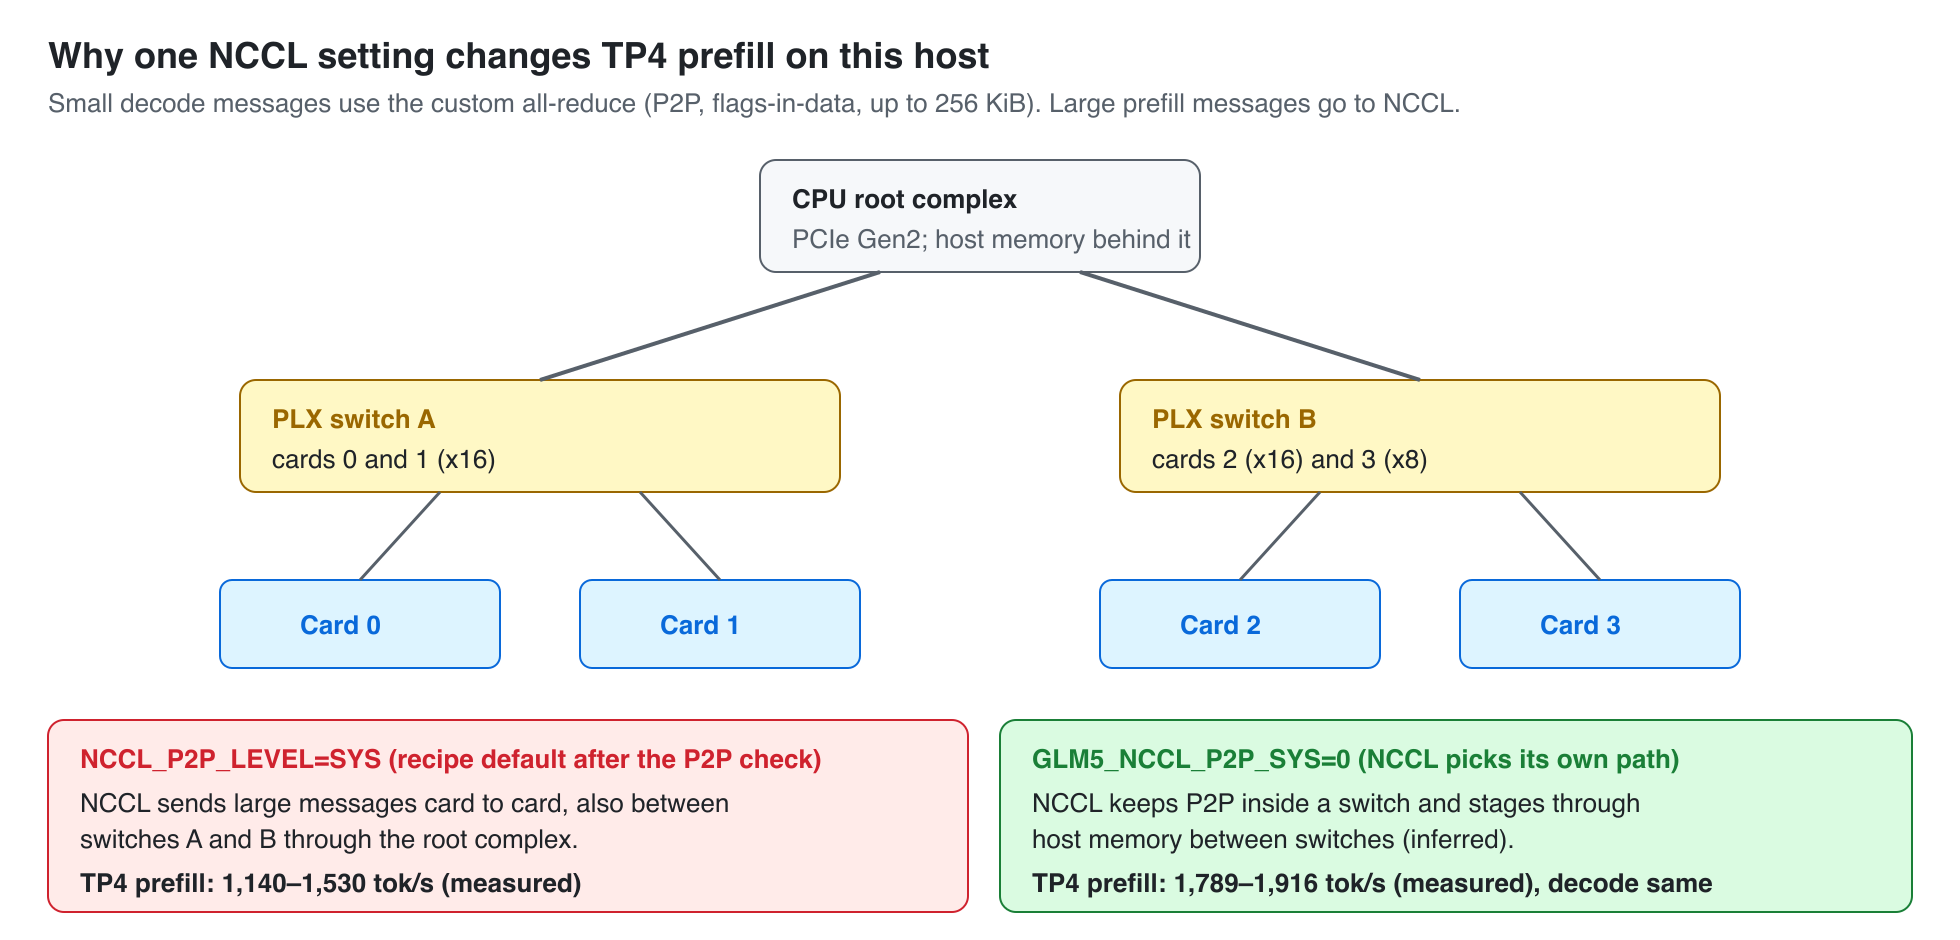

After a passed P2P check, the recipe sets `NCCL_P2P_LEVEL=SYS` for TP and PP (`GLM5_NCCL_P2P_SYS=1`). On this host the cards sit on two PLX switches, and traffic between the switches crosses the CPU root complex (`nvidia-smi topo -m`: PIX inside a pair, PHB across pairs). With `GLM5_NCCL_P2P_SYS=0`, NCCL chooses its own path. TP4 prefill is 25–57% faster, and decode does not change, because decode messages stay under the custom all-reduce's 256 KiB limit. The same setting cost 15% of prefill for DeepSeek-V4-Flash-Vision on this host (2026-10-04 notebook). The PP4 runs kept the recipe default (`SYS` on); PP4 with `SYS` off is untested.

## 4. Power (measured at x8)

- TP4: 180 W gives +0.9% to +2.6% on single-user decode and no prefill change. At 140 W, TP4 is not limited by power on this host.
- PP4: 180 W gives +0.3% on single-user decode, +36% on eight-user decode and +20% on prefill. With eight users or long prompts, all four stages work at the same time, so total power rises.
- The served configuration (TP4) stays at the host default of 140 W.

In [6]:
def telemetry(run):
    p = f"{RECEIPTS}/{run}/telemetry.csv"
    t, w = [], []
    for r in list(csv.reader(open(p), skipinitialspace=True))[1:]:
        try: t.append(float(r[2])); w.append(float(r[3].split()[0]))
        except (ValueError, IndexError): pass
    return t, w
rows = []
for run, lab in RUNS:
    t, w = telemetry(run)
    rows.append([lab, f"{max(t):.0f}", f"{statistics.mean(w):.0f}", f"{max(w):.0f}"])
table(["configuration", "peak core °C", "mean W per card", "peak sampled W"], rows)

| configuration | peak core °C | mean W per card | peak sampled W |
|---|---:|---:|---:|
| TP4, recipe default (SYS on), 140 W | 66 | 109 | 169 |
| TP4, SYS off, 140 W (served) | 67 | 116 | 167 |
| TP4, SYS off, 180 W | 69 | 127 | 194 |
| PP4, 140 W | 68 | 118 | 215 |
| PP4, 180 W | 72 | 146 | 255 |

## 5. Compared with recipe 1.6.0 on this host (measured)

Source: [2026-10-02 notebook](2026-10-02-glm-5.3-flash-4card-tp4-sm74-hbm-power-vllm.ipynb) (recipe 1.6.0, TP4, P2P off, 140 W, HBM clock equalised at 1,728 MHz) and [2026-10-01 notebook](2026-10-01-glm-5.3-flash-morrowmake-1.6.0-4card-tp4-vllm.ipynb) (1.6.0 with BAR1 P2P on).

| TP4, 140 W | 1u struct | 1u code | 1u prose | 8u struct |
|---|---:|---:|---:|---:|
| 1.6.0, P2P off (2026-10-02) | 412.7 | 305.9 | 211.6 | 814.2 |
| 1.6.0, P2P on (2026-10-01, before the 74-SM and power changes) | 293.4 | 228.7 | 154.3 | 450.6 |
| 1.7.0, P2P on, SYS off, one card x8 (section 2) | 450.8 | 352.4 | 184.6 | 762.4 |
| **1.7.0 + loop fix, P2P on, SYS off, all x16 (section 8, served)** | **464.2** | **357.8** | 186.7 | **845.7** |

- 1.7.0 with verified P2P is the first P2P-on run on this host that beats P2P off: +9% structured and +15% code for one user.
- Prose (−13%) and eight-user structured (−6%) are lower than 1.6.0 P2P off. HBM ran at 1,728 MHz on all four cards in both runs (170tune `mclk-status`: NDIV 64, PLL locked). Prose depends most on draft acceptance (1.66 accepted per step here). Not investigated further.

## 6. Gap to the recipe's published numbers (inferred)

- Served (all x16): single-user decode is at 96% / 80% / 89% (structured / code / prose), eight-user decode at 79–89%, TP4 prefill at 79–87%. With one card at x8 it was 94% / 79% / 88%, 74–81% and 60%.
- Power is not the cause for TP4 (section 4). The published numbers use x16 links on every card; here one card runs at x8, and all links are PCIe Gen2 behind two switches. TP4 sends two all-reduces in each layer, so link width and the switch crossing matter most for TP4. Section 8 tests the link width (measured): with all four cards at x16, TP4 prefill reaches 79–87% of the published figure and eight-user decode 79–89%. One-user decode stays at 80–96%. Link width and power (section 4) do not explain that gap; its cause is not measured.
- Measured: HBM is equalised at 1,728 MHz on all four cards (170tune `mclk-status`: NDIV 64, PLL locked, applied at boot by `170tune-persist`). `nvidia-smi --query-gpu=clocks.mem` still reports 1,458 MHz on cards 1 and 2: it shows the stock VBIOS value, not the live PLL. HBM is not the cause of the gap.

## 8. Update: all four cards at x16, and P2P on vs off (measured)

After a host restart, the card that linked at Gen2 x8 links at Gen2 x16 (`nvidia-smi-start.csv` in each run). Nothing else changed: same recipe, `.env`, 140 W, HBM 1,728 MHz on all four cards. Three runs on consecutive boots:

- **stock, x16:** the recipe's image, the served configuration of section 2.
- **fixed, x16:** the same with the [RecoverSSM loop fix](2026-10-04-glm-5.3-flash-v1.7.0-recoverssm-loop-fix-4card-tp4-vllm.ipynb) (`ghcr.io/pixelml/club-170hx@sha256:f9fc947bb4f1fdacd5e146948cb64cdca01da0942809989d32a6241886defaf0`). It is the image now served.
- **fixed, x16, P2P off:** `P2P=off` in `.env`. The engine then uses host shared-memory all-reduce (`HOSTSHM`) and NCCL instead of the P2P custom all-reduce.

In [7]:
X16 = [("glm-v170-tp4-nosys-140", "stock, one card x8 (section 2)"),
       ("glm-v170-stock-tp4-x16-140", "stock, all x16"),
       ("glm-v170-kdafix-tp4-x16-140", "fixed, all x16, P2P on (served)"),
       ("glm-v170-kdafix-tp4-x16-140-p2poff", "fixed, all x16, P2P off")]
rows = []
for run, lab in X16:
    pf = prefill(run)
    rows.append([lab] + [f"{dec(run, p, 1):.1f}" for p in PROMPTS] + [f"{dec(run, p, 8):.1f}" for p in PROMPTS]
                + [f"{min(pf):,.0f}–{max(pf):,.0f}"])
rows.append(["Recipe v1.7.0 published, TP4 (180 W, x16)"] + [f"{v}" for v in THEIRS["TP4"]["c1"]] + [f"{v}" for v in THEIRS["TP4"]["c8"]] + ["3,197"])
table(["configuration (TP4, 140 W)", "1u struct", "1u code", "1u prose", "8u struct", "8u code", "8u prose", "prefill tok/s"], rows)
pm = lambda r: statistics.median(prefill(r))
def delta(a, b, c):
    return " / ".join(f"{(dec(b, p, c) / dec(a, p, c) - 1) * 100:+.0f}%" for p in PROMPTS)
def compare(lab, a, b):
    return [lab, delta(a, b, 1), delta(a, b, 8), f"{(pm(b) / pm(a) - 1) * 100:+.0f}%"]
table(["comparison", "1 user (struct / code / prose)", "8 users", "prefill (median)"],
      [compare("x8 → x16 (stock image)", X16[0][0], X16[1][0]),
       compare("stock → fixed image (x16)", X16[1][0], X16[2][0]),
       compare("P2P on → P2P off (fixed, x16)", X16[2][0], X16[3][0])])

| configuration (TP4, 140 W) | 1u struct | 1u code | 1u prose | 8u struct | 8u code | 8u prose | prefill tok/s |
|---|---:|---:|---:|---:|---:|---:|---:|
| stock, one card x8 (section 2) | 450.8 | 352.4 | 184.6 | 762.4 | 616.9 | 498.5 | 1,789–1,911 |
| stock, all x16 | 464.5 | 357.5 | 186.6 | 844.5 | 671.3 | 543.1 | 2,523–2,766 |
| fixed, all x16, P2P on (served) | 464.2 | 357.8 | 186.7 | 845.7 | 670.7 | 543.5 | 2,524–2,769 |
| fixed, all x16, P2P off | 418.4 | 324.3 | 167.8 | 846.1 | 708.7 | 565.6 | 2,999–3,040 |
| Recipe v1.7.0 published, TP4 (180 W, x16) | 482.2 | 447.7 | 210.6 | 948.6 | 834.1 | 684.6 | 3,197 |

| comparison | 1 user (struct / code / prose) | 8 users | prefill (median) |
|---|---:|---:|---:|
| x8 → x16 (stock image) | +3% / +1% / +1% | +11% / +9% / +9% | +44% |
| stock → fixed image (x16) | -0% / +0% / +0% | +0% / -0% / +0% | +0% |
| P2P on → P2P off (fixed, x16) | -10% / -9% / -10% | +0% / +6% / +4% | +10% |

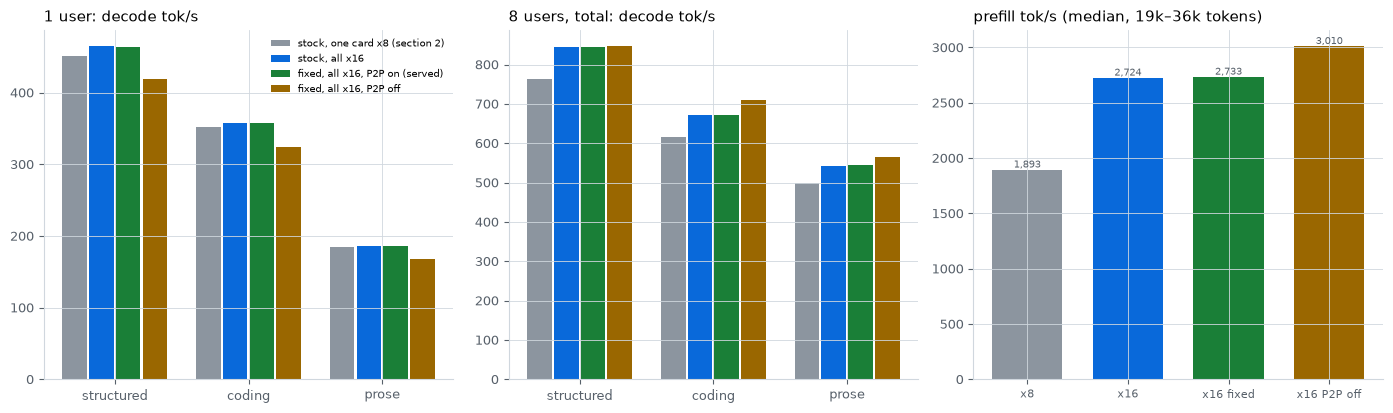

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
cols = [S[0], S[1], S[2], S[3]]
w = 0.2
for i, (run, lab) in enumerate(X16):
    for ax, c in ((axes[0], 1), (axes[1], 8)):
        ax.bar([j + (i - 1.5) * w for j in range(3)], [dec(run, p, c) for p in PROMPTS], w * 0.92, color=cols[i], label=lab)
    axes[2].bar(i, pm(run), 0.7, color=cols[i])
    axes[2].text(i, pm(run), f"{pm(run):,.0f}", ha="center", va="bottom", fontsize=7, color=INK2)
for ax, c in ((axes[0], 1), (axes[1], 8)):
    ax.set_xticks(range(3), PROMPTS); ax.set_title(f"{'1 user' if c == 1 else '8 users, total'}: decode tok/s", loc="left")
axes[2].set_xticks(range(4), ["x8", "x16", "x16 fixed", "x16 P2P off"], fontsize=8); axes[2].set_title("prefill tok/s (median, 19k–36k tokens)", loc="left")
axes[0].legend(fontsize=7, frameon=False, loc="upper right")
fig.tight_layout()
for ext in ("png", "svg"):
    fig.savefig(f"../assets/charts/2026-10-04-glm-5.3-flash-morrowmake-v1.7.0-4card-tp4-x16-p2p-vllm.{ext}", dpi=150)
plt.show()

- **Measured:** the x8 link limited TP4 prefill most: +41–45% at x16. Eight-user decode gains 9–11%; one-user decode gains 1–3%, because one-user decode messages are small.
- **Measured:** the fix image matches the stock image within 0.3% on every cell.
- **Measured:** P2P works on this host with recipe 1.7.0 (the recipe's content check passes on every boot that runs it). For one user it is 10–11% faster than P2P off. With recipe 1.6.0, P2P on was slower than P2P off here (2026-10-01 notebook); 1.7.0's verified P2P all-reduce removes that regression.
- **Measured:** P2P off prefills 10% faster (2,999–3,040 tok/s, 94–95% of the published TP4 figure) and serves eight users 4–6% faster on code and prose. Choose P2P off for long-prompt or batch work, P2P on for interactive chat and agents.
- **Inferred:** the first fixed-image boot after the host restart was a container auto-restart and logged no `[p2p]` line. Its numbers match the stock P2P-on boot within 0.3% and differ from the P2P-off boot, so P2P was on (`launch.txt`).

## 7. Reproduce

Hardware: 4 × CMP 170HX with the 64 GiB / 74-SM driver and working BAR1 P2P (the recipe's check must pass), about 190 GB of disk.

```bash
git clone https://github.com/Morrowmake/glm53-flash-cmp170hx-recipe && cd glm53-flash-cmp170hx-recipe
git checkout e61ba680cd6f9497291cafa4ca13ac3ffbdab844
# Only if docker --gpus does not work on your host (LXC with CDI): results/2026-10-04-glm-5.3-flash-morrowmake-v1.7.0-4card-tp4-pp4-p2p-vllm/build/start.sh.patch
cat > .env <<'EOF'
LAYOUT=tp4
P2P=auto
GLM5_NCCL_P2P_SYS=0
EOF
./start.sh          # pulls ghcr.io/morrowmake/vllm-cmp170hx@sha256:158627a705b6ae24fa63ba6eb454982454c5e6b94b1e32981faf33eb81a7ea3e, fetches the checkpoints, starts, waits for /health
./start.sh smoke
```

The first boot took about 40 minutes here (cold compile caches); later boots took 5–8 minutes. Benchmarks: `bench_decode.py`, `bench_long.py`, `bench_glm.sh` and `glm_chain.sh` (the option chain with an 80 °C watchdog) in `results/2026-10-04-glm-5.3-flash-morrowmake-v1.7.0-4card-tp4-pp4-p2p-vllm/`. For PP4: `LAYOUT=pp4`. For 180 W: `nvidia-smi -pl 180`. For section 8's P2P-off run: `P2P=off` in `.env`. For the fixed image: add `IMAGE=ghcr.io/pixelml/club-170hx@sha256:f9fc947bb4f1fdacd5e146948cb64cdca01da0942809989d32a6241886defaf0`.

## Try your own prompt

Edit `PROMPT`. With `LIVE = False`, the cell prints the recorded single-user decode summary of the served configuration (all x16, loop fix).

In [9]:
PROMPT = "Write a haiku about PCIe."
if LIVE:
    import urllib.request
    url = os.environ[ENDPOINT_ENV_VAR]
    body = {"model": "glm-5.3-flash", "messages": [{"role": "user", "content": PROMPT}], "max_tokens": 400}
    req = urllib.request.Request(url + "/chat/completions", json.dumps(body).encode(), {"Content-Type": "application/json"})
    resp = json.load(urllib.request.urlopen(req, timeout=600))
    m = resp["choices"][0]["message"]
    print(m.get("content")); print(resp["usage"])
else:
    d = load(RECEIPTS, "glm-v170-kdafix-tp4-x16-140", "decode-structured-c1.json")
    print({k: d[k] for k in ("phase", "tok_s_median", "accepted_per_step_median", "completion_tokens_median")})

{'phase': 'structured-c1', 'tok_s_median': 464.221925240175, 'accepted_per_step_median': 6.692, 'completion_tokens_median': 400.0}


<details><summary>Appendix: notes</summary>

- The recipe's `start.sh` uses `docker run --gpus all`. In this LXC host that flag fails, so one line uses the CDI device instead (`build/start.sh.patch`). Nothing else in the recipe changed.
- The recipe defaults: DFlash2 drafter, 262,144-token context, verified P2P, compiled Marlin decode, flags-in-data all-reduce.
- The drafter licence (CC BY-NC-ND 4.0) restricts commercial use.
- The 2026-10-01 and 2026-10-02 notebooks measured recipe 1.6.0 on this host (section 5).
</details>